<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:36px 40px;border-radius:12px;margin-bottom:8px;">
  <div style="display:flex;align-items:center;gap:16px;">
    <span style="font-size:48px;">🛰️</span>
    <div>
      <p style="color:#ADE8F4;margin:0;font-size:13px;letter-spacing:3px;text-transform:uppercase;font-family:monospace;">Computer Vision for Remote Sensing · Bangladesh</p>
      <h1 style="color:#FFFFFF;margin:4px 0 0 0;font-size:28px;font-family:monospace;">Phase 1 · Raster CV Foundations</h1>
    </div>
  </div>
  <hr style="border-color:#1E88E5;margin:20px 0 16px 0;"/>
  <div style="display:flex;gap:32px;flex-wrap:wrap;">
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📘 Lesson <b style="color:#FFF">L6 / 7</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">⏱ Est. Time <b style="color:#FFF">3 hrs</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📍 Study Area <b style="color:#FFF">Sitakunda patches</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📅 Date <b style="color:#FFF">____-__-__</b></span>
  </div>
</div>
<div style="background:#1565C022;border-left:5px solid #1565C0;padding:18px 24px;border-radius:0 8px 8px 0;">
  <h2 style="color:#1565C0;margin:0 0 8px 0;font-size:18px;">📖 L6 — Normalization for Deep Learning</h2>
  <p style="margin:0;color:#1A2A3A;font-size:14px;">📝 <i>Add lesson description here — what is this lesson about?</i></p>
</div>

## 🎯 Objectives

By the end of this lesson you will be able to:

- ✅ _Objective 1_
- ✅ _Objective 2_
- ✅ _Objective 3_

---

## 🔑 Key Functions

| Function | Purpose |
|---|---|
| `function()` | description |


---
## ⚙️ Setup & Imports

In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import json
from pathlib import Path

URL = "https://raw.githubusercontent.com/rasterio/rasterio/master/tests/data/RGB.byte.tif"

with rasterio.open(URL) as src:
    raw       = src.read(masked=True).astype(np.float32)
    profile   = src.profile
    nodata    = src.nodata
    crs       = src.crs
    transform = src.transform

print("─" * 50)
print(f"Shape      : {raw.shape}  (bands × rows × cols)")
print(f"Dtype      : {raw.dtype}")
print(f"CRS        : {crs}")
print(f"NoData val : {nodata}")
print(f"Band-1 raw : min={raw[0].min():.1f}  max={raw[0].max():.1f}")
print("─" * 50)

──────────────────────────────────────────────────
Shape      : (3, 718, 791)  (bands × rows × cols)
Dtype      : float32
CRS        : EPSG:32618
NoData val : 0.0
Band-1 raw : min=1.0  max=255.0
──────────────────────────────────────────────────


In [4]:
def fill_nodata(arr):
    """Convert a masked rasterio array to float32 with NaN where masked."""
    if isinstance(arr, np.ma.MaskedArray):
        return arr.filled(np.nan).astype(np.float32)
    return arr.astype(np.float32)


img = fill_nodata(raw)

n_nodata = np.isnan(img).sum()
n_total  = img.size

print(f"NoData pixels : {n_nodata:,} / {n_total:,}  ({n_nodata/n_total*100:.1f}%)")
print(f"Valid pixels  : {n_total - n_nodata:,}")
print(f"Band-1 range  : {np.nanmin(img[0]):.1f} – {np.nanmax(img[0]):.1f}")

NoData pixels : 555,356 / 1,703,814  (32.6%)
Valid pixels  : 1,148,458
Band-1 range  : 1.0 – 255.0


In [5]:
def minmax_normalize(arr):
    """
    Per-band Min-Max normalization.
    arr   : (C, H, W) float32, NaN for NoData
    returns normed array [0,1] and list of {min, max} per band
    """
    normed = np.empty_like(arr)
    stats  = []
    for b in range(arr.shape[0]):
        lo = np.nanmin(arr[b])
        hi = np.nanmax(arr[b])
        normed[b] = (arr[b] - lo) / (hi - lo + 1e-8)
        stats.append({"min": float(lo), "max": float(hi)})
    return normed, stats


img_mm, mm_stats = minmax_normalize(img)

print("Min-Max stats (per band):")
for i, s in enumerate(mm_stats):
    print(f"  Band {i+1}: raw [{s['min']:.1f}, {s['max']:.1f}]  →  normed [0.000, 1.000]")

print(f"\nNaN preserved? {np.isnan(img_mm).sum() == np.isnan(img).sum()}")

Min-Max stats (per band):
  Band 1: raw [1.0, 255.0]  →  normed [0.000, 1.000]
  Band 2: raw [1.0, 255.0]  →  normed [0.000, 1.000]
  Band 3: raw [1.0, 255.0]  →  normed [0.000, 1.000]

NaN preserved? True


In [6]:
def minmax_normalize(arr):
    """
    Per-band Min-Max normalization.
    arr   : (C, H, W) float32, NaN for NoData
    returns normed array [0,1] and list of {min, max} per band
    """
    normed = np.empty_like(arr)
    stats  = []
    for b in range(arr.shape[0]):
        lo = np.nanmin(arr[b])
        hi = np.nanmax(arr[b])
        normed[b] = (arr[b] - lo) / (hi - lo + 1e-8)
        stats.append({"min": float(lo), "max": float(hi)})
    return normed, stats


img_mm, mm_stats = minmax_normalize(img)

print("Min-Max stats (per band):")
for i, s in enumerate(mm_stats):
    print(f"  Band {i+1}: raw [{s['min']:.1f}, {s['max']:.1f}]  →  normed [0.000, 1.000]")

print(f"\nNaN preserved? {np.isnan(img_mm).sum() == np.isnan(img).sum()}")

Min-Max stats (per band):
  Band 1: raw [1.0, 255.0]  →  normed [0.000, 1.000]
  Band 2: raw [1.0, 255.0]  →  normed [0.000, 1.000]
  Band 3: raw [1.0, 255.0]  →  normed [0.000, 1.000]

NaN preserved? True


In [7]:
def zscore_normalize(arr, means=None, stds=None):
    """
    Per-band Z-score normalization.
    Pass pre-computed means/stds from the full training set for inference.
    If None, computes from this array (fine for single-image experiments).
    """
    if means is None:
        means = [float(np.nanmean(arr[b])) for b in range(arr.shape[0])]
    if stds is None:
        stds  = [float(np.nanstd(arr[b]))  for b in range(arr.shape[0])]

    normed = np.empty_like(arr)
    for b in range(arr.shape[0]):
        normed[b] = (arr[b] - means[b]) / (stds[b] + 1e-8)
    return normed, means, stds


img_zs, means, stds = zscore_normalize(img)

print("Z-score stats (per band):")
for b, (m, s) in enumerate(zip(means, stds)):
    post_mean = np.nanmean(img_zs[b])
    post_std  = np.nanstd(img_zs[b])
    print(f"  Band {b+1}: μ_raw={m:.1f}  σ_raw={s:.1f}"
          f"  →  μ_norm={post_mean:.4f}  σ_norm={post_std:.4f}")

Z-score stats (per band):
  Band 1: μ_raw=44.4  σ_raw=58.5  →  μ_norm=-0.0000  σ_norm=1.0000
  Band 2: μ_raw=66.0  σ_raw=58.2  →  μ_norm=0.0000  σ_norm=1.0000
  Band 3: μ_raw=71.4  σ_raw=60.8  →  μ_norm=0.0000  σ_norm=1.0000


In [8]:
def s2_to_reflectance(arr, scale=10_000.0, clip_max=1.0):
    """
    Convert Sentinel-2 DN → Surface Reflectance.
    arr      : (C, H, W) float32, NaN already in place of NoData
    scale    : 10 000 for L2A products
    clip_max : clips rare >1.0 outliers (sun glint, snow)
    """
    return np.clip(arr / scale, 0.0, clip_max)


# Demo on a synthetic 1-band 3×3 Sentinel-2 patch
fake_dn = np.array([[[845,  920, 1100],
                      [760,  880,  950],
                      [500,  300,    0]]], dtype=np.float32)

fake_refl = s2_to_reflectance(fake_dn)

print("Synthetic S2:  DN  →  Reflectance")
for col in range(3):
    print(f"  {int(fake_dn[0,0,col]):5d}  →  {fake_refl[0,0,col]:.4f}")

Synthetic S2:  DN  →  Reflectance
    845  →  0.0845
    920  →  0.0920
   1100  →  0.1100


---
## 1 · _Section Title_

> 📝 Add explanation here.

In [10]:
# Your code here
import tempfile, urllib.request, os

def compute_dataset_stats(patch_paths):
    """
    Welford online mean/variance over all valid pixels across every patch.
    patch_paths : list of str or Path pointing to GeoTIFF files
    Returns dict with 'mean', 'std', 'n_bands', 'n_patches'
    """
    n = m = s = None

    for path in patch_paths:
        with rasterio.open(path) as src:
            arr = src.read(masked=True).astype(np.float64).filled(np.nan)

        if n is None:
            C = arr.shape[0]
            n, m, s = (np.zeros(C) for _ in range(3))

        for b in range(C):
            valid = arr[b][~np.isnan(arr[b])].ravel()
            for x in valid:
                n[b]  += 1
                delta  = x - m[b]
                m[b]  += delta / n[b]
                s[b]  += delta * (x - m[b])

    std = np.sqrt(s / (n - 1))
    return {"mean": m.tolist(), "std": std.tolist(),
            "n_bands": int(C), "n_patches": len(patch_paths)}


# Download test TIF to a temp file so we can pass a file path
with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
    tmp_path = tmp.name

urllib.request.urlretrieve(URL, tmp_path)
stats = compute_dataset_stats([tmp_path])
os.unlink(tmp_path)

print("Dataset statistics:")
for b, (mv, sv) in enumerate(zip(stats["mean"], stats["std"])):
    print(f"  Band {b+1}: mean={mv:.4f}  std={sv:.4f}")

# Save
STATS_PATH = Path("../../data/dataset_stats.json")
STATS_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(STATS_PATH, "w") as f:
    json.dump(stats, f, indent=2)

print(f"\nSaved → {STATS_PATH}")

# Load back
with open(STATS_PATH) as f:
    loaded_stats = json.load(f)

print("Reload check:", loaded_stats["mean"])

Dataset statistics:
  Band 1: mean=44.4345  std=58.4901
  Band 2: mean=66.0220  std=58.2035
  Band 3: mean=71.3932  std=60.8274

Saved → ..\..\data\dataset_stats.json
Reload check: [44.434478650698196, 66.02203484105674, 71.39316199120506]


In [11]:
import torch
from torchvision import transforms

MEAN = loaded_stats["mean"]
STD  = loaded_stats["std"]

# Training transform (augmentation included)
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
])

# Validation / inference (no augmentation)
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Apply to our patch — ToTensor expects uint8 HWC
patch_hwc = np.transpose(img, (1, 2, 0))                  # CHW → HWC
patch_u8  = np.clip(patch_hwc, 0, 255).astype(np.uint8)

tensor = val_transform(patch_u8)

print(f"Input  shape : {patch_u8.shape}  dtype={patch_u8.dtype}")
print(f"Tensor shape : {tensor.shape}   dtype={tensor.dtype}")
print(f"Tensor range : [{tensor.min():.3f}, {tensor.max():.3f}]")
print(f"Band means   : {[round(tensor[b].mean().item(), 4) for b in range(3)]}")
print(f"Band stds    : {[round(tensor[b].std().item(),  4) for b in range(3)]}")

Input  shape : (718, 791, 3)  dtype=uint8
Tensor shape : torch.Size([3, 718, 791])   dtype=torch.float32
Tensor range : [-1.174, -0.743]
Band means   : [-0.7577, -1.1313, -1.1706]
Band stds    : [0.0035, 0.0038, 0.0039]


C:\Users\reza\AppData\Local\Temp\ipykernel_46032\924036734.py:24: RuntimeWarning: invalid value encountered in cast
  patch_u8  = np.clip(patch_hwc, 0, 255).astype(np.uint8)


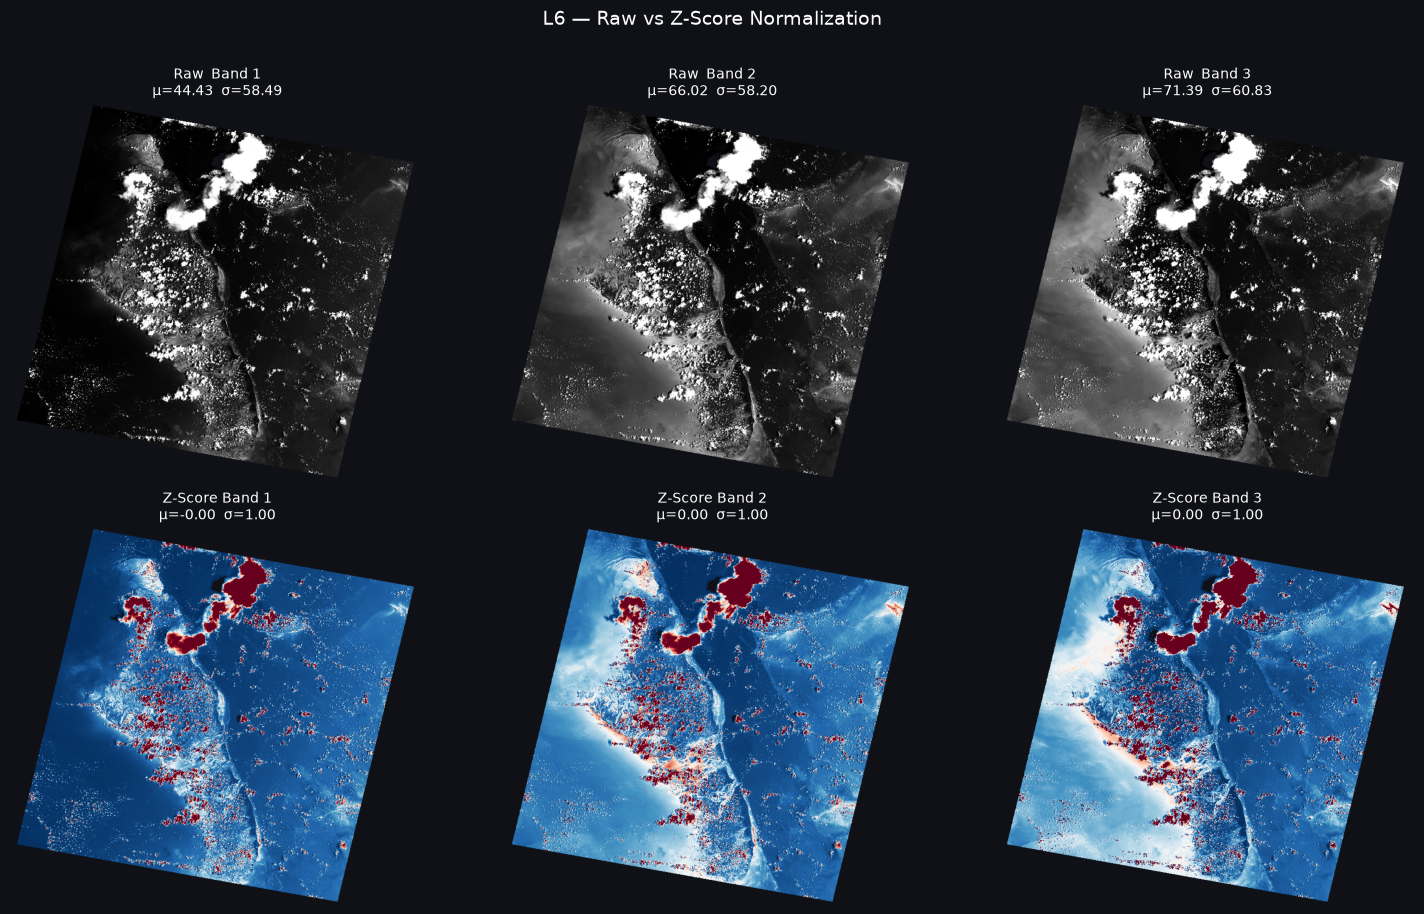

Saved → ..\..\outputs\L6_normalization_comparison.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor("#0f1117")

panels = [
    (img[0],    "Raw  Band 1",     "Greys_r"),
    (img[1],    "Raw  Band 2",     "Greys_r"),
    (img[2],    "Raw  Band 3",     "Greys_r"),
    (img_zs[0], "Z-Score Band 1",  "RdBu_r"),
    (img_zs[1], "Z-Score Band 2",  "RdBu_r"),
    (img_zs[2], "Z-Score Band 3",  "RdBu_r"),
]

for ax, (im, title, cmap) in zip(axes.ravel(), panels):
    vmin = np.nanpercentile(im, 2)
    vmax = np.nanpercentile(im, 98)
    ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"{title}\nμ={np.nanmean(im):.2f}  σ={np.nanstd(im):.2f}",
                 color="white", fontsize=10, pad=6)
    ax.axis("off")

fig.suptitle("L6 — Raw vs Z-Score Normalization",
             color="white", fontsize=14, y=1.01)
plt.tight_layout()

out = Path("../../outputs/L6_normalization_comparison.png")
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Saved → {out}")

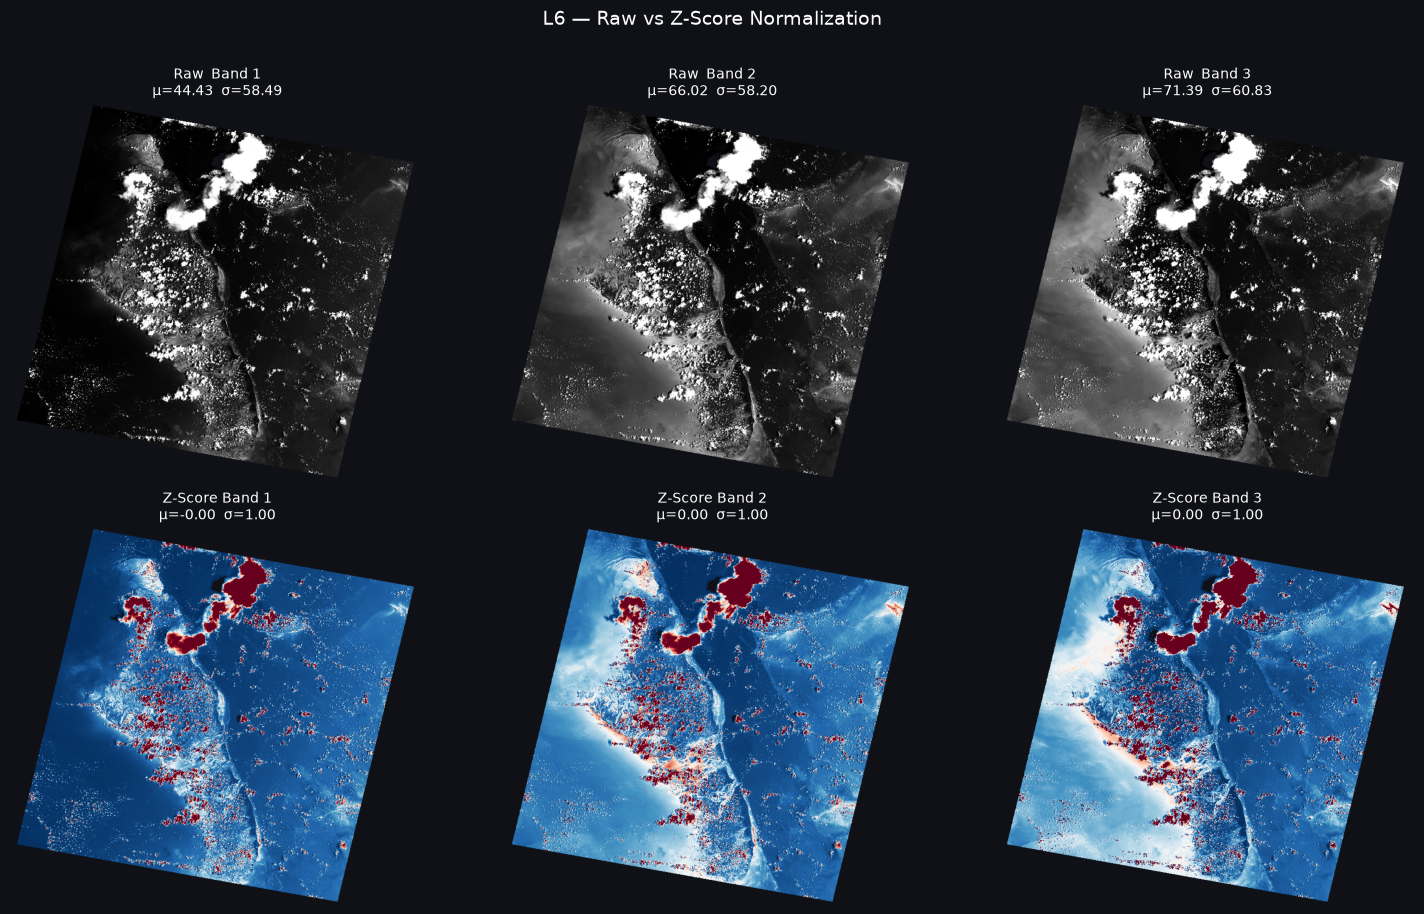

Saved → ..\..\outputs\L6_normalization_comparison.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor("#0f1117")

panels = [
    (img[0],    "Raw  Band 1",     "Greys_r"),
    (img[1],    "Raw  Band 2",     "Greys_r"),
    (img[2],    "Raw  Band 3",     "Greys_r"),
    (img_zs[0], "Z-Score Band 1",  "RdBu_r"),
    (img_zs[1], "Z-Score Band 2",  "RdBu_r"),
    (img_zs[2], "Z-Score Band 3",  "RdBu_r"),
]

for ax, (im, title, cmap) in zip(axes.ravel(), panels):
    vmin = np.nanpercentile(im, 2)
    vmax = np.nanpercentile(im, 98)
    ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"{title}\nμ={np.nanmean(im):.2f}  σ={np.nanstd(im):.2f}",
                 color="white", fontsize=10, pad=6)
    ax.axis("off")

fig.suptitle("L6 — Raw vs Z-Score Normalization",
             color="white", fontsize=14, y=1.01)
plt.tight_layout()

out = Path("../../outputs/L6_normalization_comparison.png")
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Saved → {out}")

---
## 🏋️ Exercise

<div style="background:#FFF9C4;border-left:4px solid #F9A825;padding:14px 20px;border-radius:0 8px 8px 0;">
<b>Task:</b> Normalization for Deep Learning — complete the exercise below.
</div>

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────


---
## 📝 My Notes

> _Fill in after completing the exercise._

- Observation 1: `____`
- Observation 2: `____`
- Anything unexpected: `____`


---
<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:24px 32px;border-radius:10px;">
  <h2 style="color:#FFFFFF;margin:0 0 12px 0;font-size:18px;">✅ Key Takeaways — L6</h2>
  <ul style="color:#C8E6C9;font-size:14px;line-height:2.2;margin:0;">
    <li>_Takeaway 1_</li>
    <li>_Takeaway 2_</li>
    <li>_Takeaway 3_</li>
  </ul>
</div>

---
<div style="display:flex;justify-content:space-between;padding:10px 0;font-size:13px;color:#9E9E9E;">
  <span>← Previous: <a href="L5_prev.ipynb">L5</a></span>
  <b style="color:#1565C0;">Phase 1 · L6 of 7</b>
  <span><a href="L7_next.ipynb" style="color:#1565C0;">Next: L7 →</a></span>
</div>